# Feynmanator

## Feynman diagrams from a product of propagators

`feynmanator.py` draws a Feynman diagram from the factors of a term: 

* `G(1,2)` is a Green's function (solid, no arrow; 
* `G(1,1)` a closed loop), 
* `Q(1,2)` a Coulomb line (wavy), 
* `PI(1,2)` a polarisation loop (two arcs), 
* `PIH(1,2)` a shaded one, 
* `v(1)` and `w(2)` the external lines (arrows; the first one written enters at the top left, the second leaves at the right), 
* `T(1)` a cross and `S(1,2)` a dashed line. The labels name the vertices, any letters or digits will do; nothing is drawn at a plain vertex and there are no labels, unless `energies=True` labels the lines with their energies (below).

The same exports as `goldstoninator.py` (SVG, PDF, TikZ).

In [1]:
import feynmanator as fd

First order: the exchange (Fock) and direct (Hartree, a tadpole) self-energy:

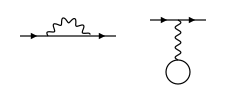

In [2]:
fd.grid(["v(1) G(1,2) w(2) Q(1,2)", "v(1) w(1) Qs(1,2) G(2,2)"], ncols=2)

Second order: the direct term with a polarisation loop `PI(3,4)`, and the exchange term, whose two Coulomb lines must cross:

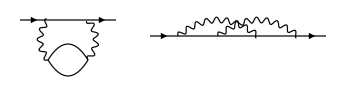

In [3]:
fd.grid(
    [
        "v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)",
        "v(1) G(1,2) G(2,3) G(3,4) w(4) Q(1,3) Q(2,4)",
    ],
    ncols=2,
)

An external field (`T`, a cross) acting directly on the valence line, through the Coulomb interaction, and through a screened interaction. A Coulomb line may end at the cross: its ends need not be fermion vertices.

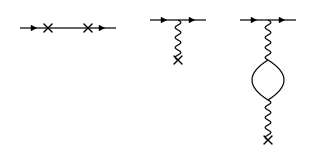

In [4]:
fd.grid(
    [
        "v(1) G(1,2) w(2) T(1) T(2)",
        "v(1) w(1) Qs(1,2) T(2)",
        "v(1) w(1) Qs(1,2) PI(2,3) Qs(3,4) T(4)",
    ],
    ncols=3,
)

Chains of bubbles (RPA screening of the Coulomb line):

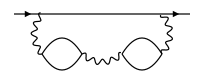

In [5]:
fd.diagram("v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,5) PI(5,6) Q(6,2)")

The full polarisation operator `PIH(1,2)` is the bubble shaded inside: hatched by default, `styles={'PIH': 'shaded'}` fills it grey and `'crosshatched'` hatches it both ways:

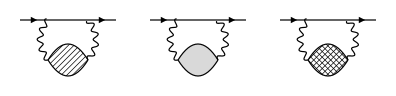

In [6]:
term = "v(1) G(1,2) w(2) Q(1,3) PIH(3,4) Q(4,2)"
fd.grid(
    [
        fd.diagram(term),
        fd.diagram(term, styles={"PIH": "shaded"}),
        fd.diagram(term, styles={"PIH": "crosshatched"}),
    ],
    ncols=3,
)

A closed loop of `G` lines is drawn counterclockwise in the direction of propagation (`G(a,b)` runs from b to a), so writing the loop the other way round mirrors it. A field insertion `t(i)` on the valence line, and on the upper or the lower line of the loop:

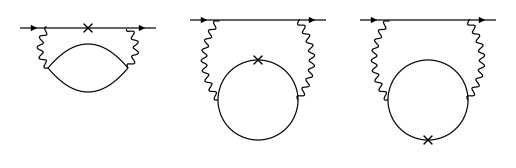

In [7]:
fd.grid(
    [
        "v(1) G(1,i) t(i) G(i,2) w(2) Q(1,3) PI(3,6) Q(6,2)",
        "v(1) G(1,2) w(2) Q(1,3) G(3,i) t(i) G(i,6) G(6,3) Q(6,2)",
        "v(1) G(1,2) w(2) Q(1,3) G(3,6) G(6,i) t(i) G(i,3) Q(6,2)",
    ]
)

Several Coulomb lines over one fermion line all bend to the same side by default; `Qu` and `Qd` force a line up or down (left or right for a vertical line) when that is not what you want:

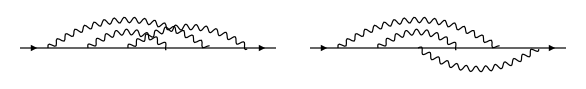

In [8]:
fd.grid(
    [
        "v(1) G(1,2) G(2,3) G(3,4) G(4,5) G(5,6) w(6) Q(1,5) Q(3,6) Q(2,4)",
        "v(1) G(1,2) G(2,3) G(3,4) G(4,5) G(5,6) w(6) Q(1,5) Qd(3,6) Q(2,4)",
    ],
    ncols=2,
)

`X(1,2)` is a second Coulomb-type line, double wavy (a screened or effective interaction, say), laid out like `Q` and with the same variants `Xs`, `Xu`, `Xd`:

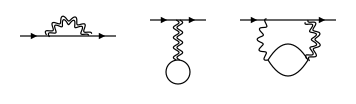

In [9]:
fd.grid(
    [
        "v(1) G(1,2) w(2) X(1,2)",
        "v(1) w(1) Xs(1,2) G(2,2)",
        "v(1) G(1,2) w(2) Q(1,3) PI(3,4) X(4,2)",
    ],
    ncols=3,
)

Any other name with two labels is a dashed line, with one label a marker; `styles=` changes them (lines `wavy`, `doublewavy`, `dashed`, `dotted`, `double`, `solid`, and `arrow` or `arrows`, a solid line with one filled or two open arrowheads pointing from the first label to the second; markers `x`, `dot`, `circle`, `square`). `styles={'G': 'double'}` draws dressed propagators; `Qs` is a Coulomb line drawn straight instead of bowed. `Gex` is the excited part of `G` (two arrowheads) and `Pa` the core projector (a double line):

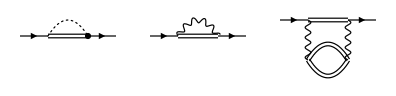

In [10]:
fd.grid(
    [
        "v(1) G(1,2) w(2) S(1,2) T(2)",
        "v(1) G(1,2) w(2) Q(1,2)",
        "v(1) G(1,2) w(2) Qs(1,3) PI(3,4) Qs(4,2)",
    ],
    ncols=3,
    styles={"S": "dotted", "T": "dot", "G": "double"},
)

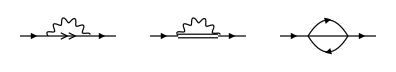

In [11]:
fd.diagram(
    [
        "v(1) Gex(1,2) w(2) Q(1,2)",
        "v(1) Pa(1,2) w(2) Q(1,2)",
        "v(1) G(1,2) w(2) S(1,2) S(2,1)",
    ],
    ncols=3,
    styles={"S": "arrow"},
)

Or for the whole session, with `fd.STYLES` (and `gd.STYLES` for the Goldstone diagrams, including those from `goldstone()` below):

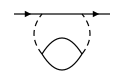

In [12]:
fd.STYLES["Q"] = "dashed"
display(fd.diagram("v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)"))
fd.STYLES["Q"] = "wavy"

The vertices sit on a small grid, with the incoming vertex leftmost, the outgoing one rightmost and the fermion line straight between them; `straight=False` frees it, `layout(cols=, rows=)` sets the grid by hand, `curved=False` draws every Coulomb line straight and `vertical=('Q',)` makes the lines of those names run vertically, as in a Goldstone diagram (with `straight=False` when they join two vertices of the fermion line):

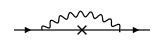

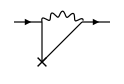

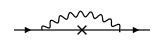

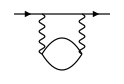

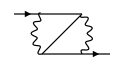

In [13]:
term = "v(1) G(1,2) G(2,3) w(3) Q(1,3) T(2)"
display(
    fd.diagram(term),
    fd.diagram(term, straight=False),
    fd.diagram(term).layout(cols=3, rows=2),
)
bubble = "v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)"
display(
    fd.diagram(bubble, curved=False),
    fd.diagram(
        "v(1) G(1,2) G(2,3) G(3,4) w(4) Q(1,3) Q(2,4)", vertical=("Q",), straight=False
    ),
)

`energies=True` labels the lines with their energies, from energy conservation at each vertex: the incoming leg carries $\varepsilon_v$, a marker `T` injects $\omega_T$, each interaction line that conservation leaves free carries its own $\omega$ ($\omega_1$, $\omega_2$, ... in the order written) and each closed fermion loop an $\varepsilon'$; the rest follows, so the two Coulomb lines round a bubble share one $\omega$. `energies()` lists them as LaTeX:

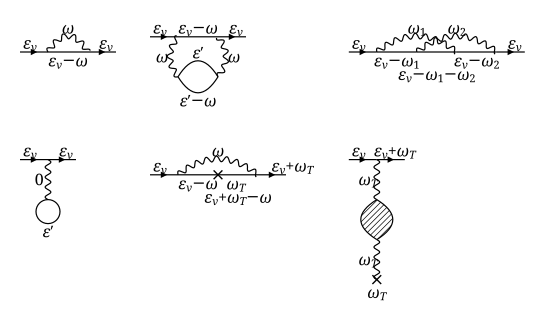

In [14]:
fd.grid(
    [
        "v(1) G(1,2) w(2) Q(1,2)",
        "v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)",
        "v(1) G(1,2) G(2,3) G(3,4) w(4) Q(1,3) Q(2,4)",
        "v(1) w(1) Qs(1,2) G(2,2)",
        "v(1) G(1,i) T(i) G(i,2) w(2) Q(1,2)",
        "v(1) w(1) Qs(1,2) PIH(2,3) Qs(3,4) T(4)",
    ],
    ncols=3,
    energies=True,
)

In [15]:
fd.diagram("v(1) G(1,i) T(i) G(i,2) w(2) Q(1,2)").energies()

{'v(1)': '\\varepsilon_{v}',
 'w(2)': '\\varepsilon_{v}+\\omega_{T}',
 'G(1,i)': '\\varepsilon_{v}-\\omega',
 'G(i,2)': '\\varepsilon_{v}+\\omega_{T}-\\omega',
 'Q(1,2)': '\\omega',
 'T(i)': '\\omega_{T}'}

`scale=` sets the size of the picture (pixels per unit) and `font=` the size of the labels (points) independently; by default the labels are 0.4 of a unit and scale with the picture. `pad=` adds margin:

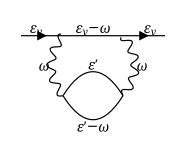

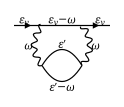

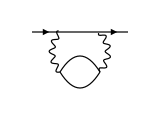

In [16]:
term = "v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)"
display(
    fd.diagram(term, energies=True, scale=60, font=14),
    fd.diagram(term, energies=True, font=11),
    fd.diagram(term, pad=0.8),
)

`goldstone()` expands a Feynman diagram into its Goldstone diagrams, one per time ordering of its interactions (Coulomb lines and markers), as a goldstoninator grid: a Coulomb line `Q(i,j)` becomes the integral $g_{pqrs}$ of the fermion lines at its ends, a marker the one-body $T_{pr}$; a fermion line forward in time is a particle, backward (or within one interaction) a hole; `Gex` is only a particle and `Pa` only a hole. The pictures, the sum with its denominators and the exports then come from goldstoninator:

['g_{mnva} g_{avnm}', 'g_{mvba} g_{abvm}']


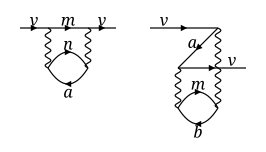

$$\begin{aligned}
&+\frac{g_{mnva}\,g_{avnm}}{(\varepsilon_{va}-\varepsilon_{mn})} \\
&+\frac{g_{mvba}\,g_{abvm}}{(\varepsilon_{vm}-\varepsilon_{ab})}
\end{aligned}$$

In [17]:
g = fd.goldstone("v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)")
print(fd.diagram("v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)").goldstone_terms())
display(g)
g.equation()

Second-order exchange, and the field vertex on the valence line through the Coulomb interaction (with `Gex` for the first propagator, only the ordering in which it is a particle survives). A list of Feynman terms gives all their Goldstone diagrams in one grid, and the keywords go to the Goldstone diagrams:

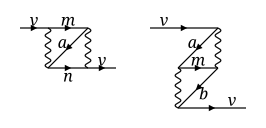

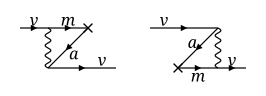

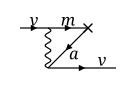

$$\begin{aligned}
&-\frac{g_{mvva}\,T_{am}}{(\varepsilon_a-\varepsilon_m-\omega_T)}
\end{aligned}$$

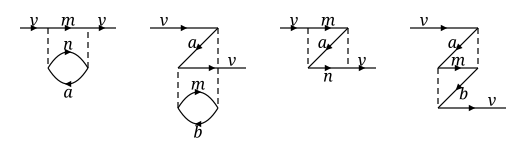

$$\begin{aligned}
&+\frac{g_{mnva}\,g_{avnm}}{(\varepsilon_{va}-\varepsilon_{mn})} \\
&+\frac{g_{mvba}\,g_{abvm}}{(\varepsilon_{vm}-\varepsilon_{ab})} \\
&-\frac{g_{mnva}\,g_{avmn}}{(\varepsilon_{va}-\varepsilon_{mn})} \\
&-\frac{g_{mvab}\,g_{abvm}}{(\varepsilon_{vm}-\varepsilon_{ab})}
\end{aligned}$$

In [18]:
display(fd.goldstone("v(1) G(1,2) G(2,3) G(3,4) w(4) Q(1,3) Q(2,4)"))
display(fd.goldstone("v(1) G(1,i) T(i) G(i,2) w(2) Q(1,2)"))
gold = fd.goldstone("v(1) Gex(1,i) T(i) G(i,2) w(2) Q(1,2)")
display(gold)
display(gold.equation())
both = fd.goldstone(
    [
        "v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)",
        "v(1) G(1,2) G(2,3) G(3,4) w(4) Q(1,3) Q(2,4)",
    ],
    ncols=4,
    styles={"g": "dashed"},
)
display(both)
both.equation()

Export: `tikz()` gives the TikZ source (a document that `\input`s it needs `\usetikzlibrary{decorations.pathmorphing}` for the wavy lines); `save('fig.svg' / 'fig.pdf' / 'fig.tikz' / 'fig.tex')` writes a file, for grids too. The README pictures are written here as PDF; converted to PNG, they are kept in `img/`.

In [19]:
d = fd.diagram("v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)")
print(d.tikz())

# the README pictures (converted to PNG, they are kept in img/)
fd.diagram(
    [
        "v(1) G(1,2) w(2) Q(1,2)",
        "v(1) w(1) Qs(1,2) G(2,2)",
        "v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)",
        "v(1) G(1,2) G(2,3) G(3,4) w(4) Q(1,3) Q(2,4)",
        "v(1) w(1) Qs(1,2) PI(2,3) Qs(3,4) T(4)",
        "v(1) G(1,i) t(i) G(i,2) w(2) Q(1,3) PI(3,6) Q(6,2)",
    ],
    ncols=3,
).save("feynman.pdf")
fd.goldstone("v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)").save("feynman-goldstone.pdf")
fd.diagram("v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)", energies=True).save("feynman-energies.pdf")

% v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)
\begin{tikzpicture}[x=1cm,y=1cm,line width=0.85pt]
\draw (0,1) -- (1,1);
\draw (-0.7,1) -- (0,1);
\draw (1,1) -- (1.7,1);
\draw[decorate,decoration={snake,amplitude=0.7mm,segment length=2.5mm}] (0,0) .. controls (-0.27,0.33) and (-0.27,0.67) .. (0,1);
\draw (0,0) .. controls (0.33,-0.53) and (0.67,-0.53) .. (1,0);
\draw (0,0) .. controls (0.33,0.53) and (0.67,0.53) .. (1,0);
\draw[decorate,decoration={snake,amplitude=0.7mm,segment length=2.5mm}] (1,0) .. controls (1.27,0.33) and (1.27,0.67) .. (1,1);
\fill (-0.27,1) -- (-0.43,1.08) -- (-0.43,0.92) -- cycle;
\fill (1.43,1) -- (1.27,1.08) -- (1.27,0.92) -- cycle;
\end{tikzpicture}


'feynman-energies.pdf'